# Geysers Preprocessing Workflow

This notebook preprocesses injection/production time series and seismic catalog data for the Geysers dataset.

## 1) Setup

In [8]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set(style="whitegrid")
SANS_SERIF_FONTS = ['Arial', 'Helvetica', 'Liberation Sans', 'Nimbus Sans', 'DejaVu Sans']
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': SANS_SERIF_FONTS,
    'mathtext.fontset': 'dejavusans',
})

DATA_ROOT = Path("../data/Geysers/raw")
CATALOG_DAT = DATA_ROOT / "geysers_catalog.dat"
INJ_CSV = DATA_ROOT / "InjData.csv"
OUT_DAILY_TS = DATA_ROOT / "daily_injection_production.csv"
OUT_CATALOG_CSV = DATA_ROOT / "geysers_catalog.csv"

START_TS = pd.Timestamp("2003-05-01")
END_TS = pd.Timestamp("2015-01-31")
MC = 2.2


## 2) Load Raw Data

In [9]:
catalog = np.loadtxt(CATALOG_DAT)
inj = pd.read_csv(INJ_CSV)
inj["Date"] = pd.to_datetime(inj["Date"])

# Keep the modeling period only and use the same volume scaling as existing pipeline.
inj = inj[inj["Date"] >= START_TS].copy()
inj["ProdVol"] = inj["ProdVol"] / 1e5
inj["InjVol"] = inj["InjVol"] / 1e5

pd.Series({
    "catalog_rows": int(catalog.shape[0]),
    "inj_rows": int(len(inj)),
    "inj_date_min": inj["Date"].min(),
    "inj_date_max": inj["Date"].max(),
})


catalog_rows                 412394
inj_rows                        141
inj_date_min    2003-05-31 00:00:00
inj_date_max    2015-01-31 00:00:00
dtype: object

## 3) Convert Monthly Injection/Production to Daily Series

In [10]:
inj["days_in_month"] = inj["Date"].dt.days_in_month
inj["ProdVol_per_day"] = inj["ProdVol"] / inj["days_in_month"]
inj["InjVol_per_day"] = inj["InjVol"] / inj["days_in_month"]

daily_parts = []
for _, row in inj.iterrows():
    start_day = row["Date"].replace(day=1)
    end_day = row["Date"]
    days = pd.date_range(start=start_day, end=end_day, freq="D")
    chunk = pd.DataFrame({
        "Date": days,
        "ProdVol_daily": row["ProdVol_per_day"],
        "InjVol_daily": row["InjVol_per_day"],
    })
    daily_parts.append(chunk)

daily_df = pd.concat(daily_parts, ignore_index=True)
daily_df = daily_df.groupby("Date", as_index=False)[["ProdVol_daily", "InjVol_daily"]].sum()
daily_df = daily_df.sort_values("Date").reset_index(drop=True)
daily_df = daily_df[(daily_df["Date"] >= START_TS) & (daily_df["Date"] <= END_TS)].copy()
daily_df["t"] = (daily_df["Date"] - START_TS).dt.total_seconds() / 86400.0

# Ensure continuous daily coverage for the configured date range.
full_dates = pd.date_range(START_TS, END_TS, freq="D")
daily_df = daily_df.set_index("Date").reindex(full_dates).fillna(0.0).rename_axis("Date").reset_index()
daily_df["t"] = (daily_df["Date"] - START_TS).dt.total_seconds() / 86400.0

daily_df.to_csv(OUT_DAILY_TS, index=False)

pd.Series({
    "daily_rows": int(len(daily_df)),
    "daily_date_min": daily_df["Date"].min(),
    "daily_date_max": daily_df["Date"].max(),
    "daily_missing": int(daily_df[["ProdVol_daily", "InjVol_daily"]].isna().sum().sum()),
})


daily_rows                       4294
daily_date_min    2003-05-01 00:00:00
daily_date_max    2015-01-31 00:00:00
daily_missing                       0
dtype: object

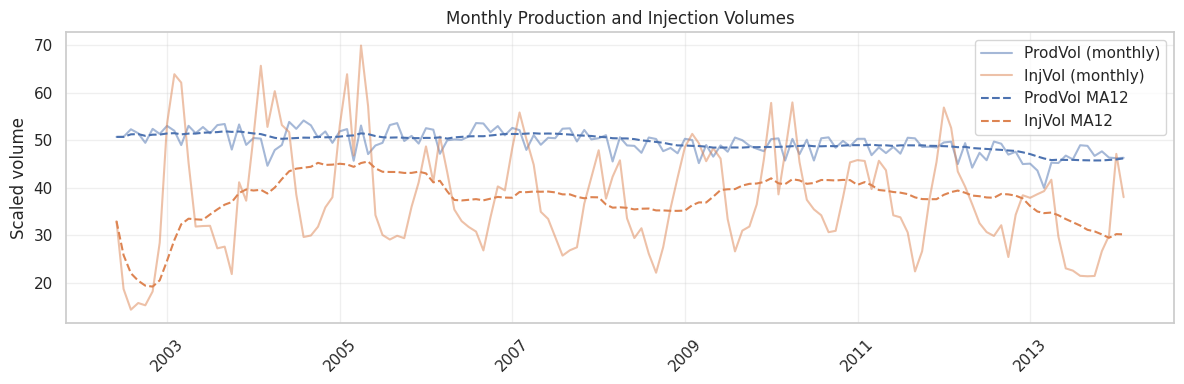

In [11]:
inj_plot = inj.set_index("Date").copy()
inj_plot[["ProdVol_MA12", "InjVol_MA12"]] = inj_plot[["ProdVol", "InjVol"]].rolling(12, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(inj_plot.index, inj_plot["ProdVol"], label="ProdVol (monthly)", color="C0", alpha=0.5)
ax.plot(inj_plot.index, inj_plot["InjVol"], label="InjVol (monthly)", color="C1", alpha=0.5)
ax.plot(inj_plot.index, inj_plot["ProdVol_MA12"], "--", label="ProdVol MA12", color="C0")
ax.plot(inj_plot.index, inj_plot["InjVol_MA12"], "--", label="InjVol MA12", color="C1")
ax.set_ylabel("Scaled volume")
ax.set_title("Monthly Production and Injection Volumes")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 4) Build Processed Seismic Catalog

In [12]:
column_names = [
    "Year", "Month", "Day", "Hour", "Minute", "Second",
    "Latitude", "Longitude", "Magnitude", "Depth",
]
df_raw = pd.read_csv(CATALOG_DAT, header=None, names=column_names, sep=r"\s+")

# Build timestamps while keeping fractional seconds.
base_ts = pd.to_datetime(
    df_raw[["Year", "Month", "Day", "Hour", "Minute"]].astype(int).rename(
        columns={"Year": "year", "Month": "month", "Day": "day", "Hour": "hour", "Minute": "minute"}
    ),
    errors="coerce",
)
ts = base_ts + pd.to_timedelta(df_raw["Second"], unit="s")

df = pd.DataFrame({
    "ts": ts,
    "Magnitude": df_raw["Magnitude"].astype(float),
    "Latitude": df_raw["Latitude"].astype(float),
    "Longitude": df_raw["Longitude"].astype(float),
    "Depth": df_raw["Depth"].astype(float),
})
df = df.dropna(subset=["ts"]).copy()
df = df[(df["ts"] >= START_TS) & (df["ts"] <= END_TS)].copy()
df = df.sort_values("ts").reset_index(drop=True)
df["t"] = (df["ts"] - START_TS).dt.total_seconds() / 86400.0
df["dt"] = df["t"].diff().fillna(0.0)

# Keep legacy column order expected by data loader.
df_out = df[["t", "Magnitude", "Latitude", "Longitude", "Depth", "ts", "dt"]].copy()
df_out.to_csv(OUT_CATALOG_CSV, index=False)

pd.Series({
    "catalog_rows_filtered": int(len(df_out)),
    "catalog_ts_min": df_out["ts"].min(),
    "catalog_ts_max": df_out["ts"].max(),
    "dt_nonpositive": int((df_out["dt"] <= 0).sum()),
})


catalog_rows_filtered                        375353
catalog_ts_min           2003-05-01 01:47:47.240000
catalog_ts_max           2015-01-30 23:36:23.640000
dt_nonpositive                                    1
dtype: object

## 5) Diagnostics

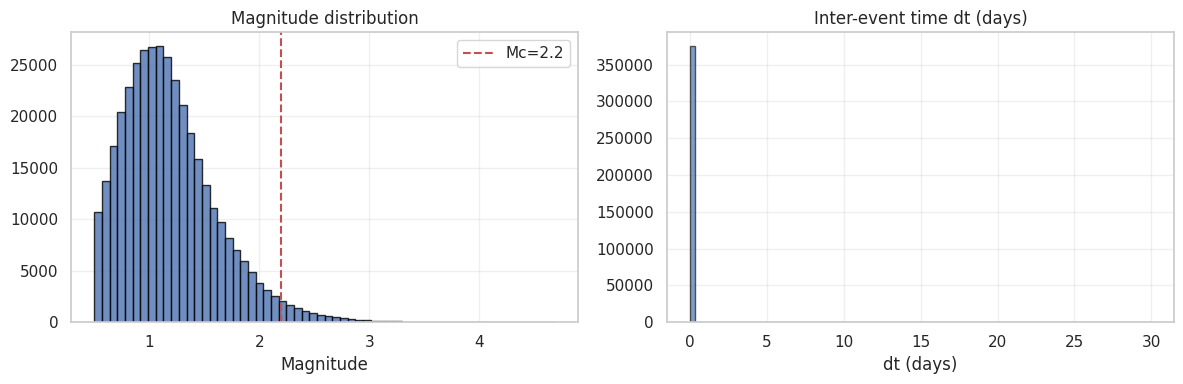

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].hist(df_out["Magnitude"], bins=60, edgecolor="black", alpha=0.8)
axs[0].axvline(MC, color="r", linestyle="--", label=f"Mc={MC}")
axs[0].set_title("Magnitude distribution")
axs[0].set_xlabel("Magnitude")
axs[0].legend()

dt = df_out["dt"]
axs[1].hist(dt, bins=100, color="C0", edgecolor="k", alpha=0.7)
axs[1].set_title("Inter-event time dt (days)")
axs[1].set_xlabel("dt (days)")

for ax in axs:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


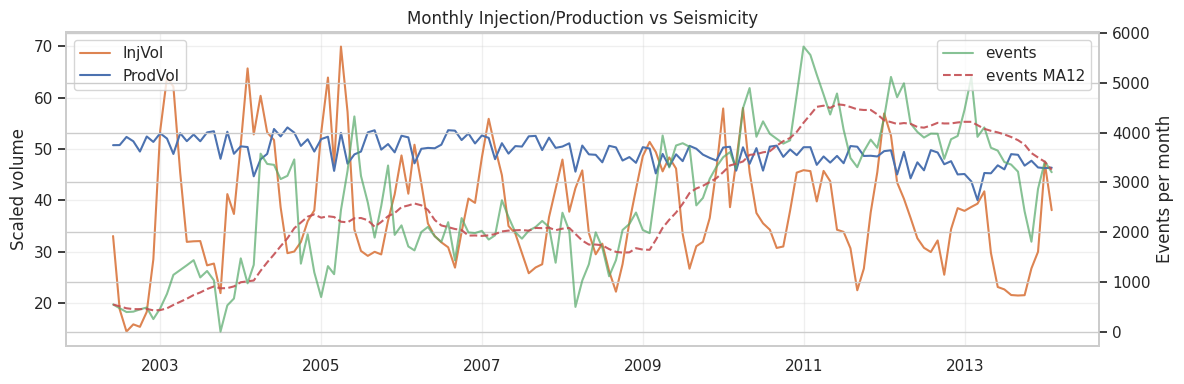

,InjVol,ProdVol,events
InjVol,1.000000,-0.038071,0.125256
ProdVol,-0.038071,1.000000,-0.428969
events,0.125256,-0.428969,1.000000


In [14]:
inj_per_month = inj.set_index("Date").resample("ME").sum()[["InjVol", "ProdVol"]]
events_per_month = df_out.set_index("ts").resample("ME").size().rename("events")
monthly = inj_per_month.join(events_per_month, how="left").fillna(0)
monthly["events_ma12"] = monthly["events"].rolling(12, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(monthly.index, monthly["InjVol"], label="InjVol", color="C1")
ax1.plot(monthly.index, monthly["ProdVol"], label="ProdVol", color="C0")
ax1.set_ylabel("Scaled volume")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["events"], label="events", color="C2", alpha=0.7)
ax2.plot(monthly.index, monthly["events_ma12"], "--", label="events MA12", color="C3", alpha=0.9)
ax2.set_ylabel("Events per month")
ax2.legend(loc="upper right")

ax1.set_title("Monthly Injection/Production vs Seismicity")
plt.tight_layout()
plt.show()

monthly[["InjVol", "ProdVol", "events"]].corr()
